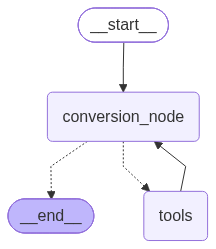


--- Final Assistant Response ---
Here are your conversions based on current exchange rates:

**100 USD to EUR:**
- Exchange Rate: 1 USD = 0.8673 EUR
- **100 USD = 86.73 EUR**

**100 GBP to JPY:**
- Exchange Rate: 1 GBP = 212.9195 JPY
- **100 GBP = 21,291.95 JPY**


In [20]:
import json
import requests
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from IPython.display import Image, display

# LangChain / Anthropic integrations
from langchain_anthropic import ChatAnthropic
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage
from langchain_core.tools import tool

# LangGraph runtime primitives
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

load_dotenv()

# ----------------------------------------------------
# 1. Define Tool with Safe Exception Handling
# ----------------------------------------------------
@tool
def get_conversion_rate(base_currency: str, target_currency: str) -> str:
    """Retrieves the current exchange rate between two specified currencies.

    Uses standard 3-letter ISO 4217 currency codes to fetch real-time exchange rates.
    """
    url = f'https://v6.exchangerate-api.com/v6/d0397a29769416a679436009/pair/{base_currency}/{target_currency}'

    try:
        response = requests.get(url, timeout=10)
        response.raise_for_status()
        data = response.json()
        return json.dumps(data)
    except requests.exceptions.RequestException as req_err:
        # Return string errors so LLM can read and handle them
        return f"Error fetching exchange rate: {str(req_err)}"


# ----------------------------------------------------
# 2. Define State & Initialize Model
# ----------------------------------------------------
class ConversionNodeState(TypedDict):
    # 'add_messages' ensures conversation history is preserved across agent tool loops
    messages: Annotated[list, add_messages]
    conversion_result: str


tools = [get_conversion_rate]

model = ChatAnthropic(
    model="claude-haiku-4-5", # Updated to standard available model identifier
    max_tokens=1024
)

model_with_tools = model.bind_tools(
    tools=tools, 
    tool_choice="auto", 
    parallel_tool_calls=False
)

# ----------------------------------------------------
# 3. Define Graph Nodes & Conditional Routing
# ----------------------------------------------------
SYSTEM_PROMPT = SystemMessage(
    content="You are a precise, single-purpose Currency Conversion Agent. "
    "Your sole task is to take a financial value in one currency specified by the user. "
    "If the user inputs something you can't understand or is ambiguous, ask for more clarity, "
    "query an external exchange rate tool, and convert that value into the target currency."
)

def conversion_node(state: ConversionNodeState) -> dict:
    messages = state["messages"]
    
    # Prepend SystemMessage if not present
    if not isinstance(messages[0], SystemMessage):
        messages = [SYSTEM_PROMPT] + messages

    # Properly call invoke to get AIMessage response
    response = model_with_tools.invoke(messages)
    
    return {
        "messages": [response],
        "conversion_result": response.content if not response.tool_calls else ""
    }

def should_continue(state: ConversionNodeState) -> str:
    """Routes execution to tools node if LLM wants to call a tool, else ends."""
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    return END

# ----------------------------------------------------
# 4. Construct LangGraph Workflow
# ----------------------------------------------------
workflow = StateGraph(ConversionNodeState)

# Add Nodes
workflow.add_node("conversion_node", conversion_node)
workflow.add_node("tools", ToolNode(tools))

# Add Edges
workflow.add_edge(START, "conversion_node")

# Conditional Edge: If tool requested -> go to "tools", else -> END
workflow.add_conditional_edges(
    "conversion_node",
    should_continue,
    {
        "tools": "tools",
        END: END
    }
)

# Loop back from tools node to conversion_node to let Claude process tool results
workflow.add_edge("tools", "conversion_node")

# Compile Runnable App
app = workflow.compile()

# Display Mermaid PNG Graph Schema
try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    pass

# ----------------------------------------------------
# 5. Example Execution Run
# ----------------------------------------------------
if __name__ == "__main__":
    initial_input = {
        "messages": [HumanMessage(content="Convert 100 USD to EUR and 100 GBP to JPY.")]
    }
    
    final_output = app.invoke(initial_input)
    print("\n--- Final Assistant Response ---")
    print(final_output["messages"][-1].content)